## Module 4: 

## Team Members:
Christian Grosso and Isabella Orlando

## Project Title:
Gene Expression For Sustained Growth Signaling In Breast Cancer



## Project Goal:
This project seeks to determine whether or not expression of sustained growth signaling genes can predict active tumor status in breast cancer.

## Disease Background:

* Cancer hallmark focus: Sustained Growth Signals
* Overview of hallmark: Cancer cells gain the ability to continuously stimulate their own growth and division without needing external signals. Normally, cells rely on regulated growth factors from their environment, but cancer cells bypass this by:

Producing their own mitogenic (growth) signals (autocrine signaling), Overexpressing or mutating growth factor receptors, and Activating downstream signaling pathways permanently

This leads to:

Increased division rate (often several-fold higher than normal),Hyperplasia (cells expanding outward from normal tissue structure), and Loss of normal growth control

* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest)

EGF / EGFR, HER2 (ERBB2), PDGF / PDGFR


We will be focusing on breast cancer.

Prevalence & incidence:
Breast cancer is the most commonly diagnosed cancer in women worldwide
In the U.S., about 1 in 8 women will develop it during their lifetime.
It is the second leading cause of cancer death in women.

Risk factors (genetic, lifestyle) & societal determinants:
Genetic:
Mutations in BRCA1 and BRCA2 significantly increase risk.
Other genes: TP53, HER2 (ERBB2)
Family history of breast cancer

Lifestyle:
Alcohol consumption
Obesity
Lack of physical activity

Societal determinants:

Access to screening, as it affects early detection
Socioeconomic status → impacts treatment access and outcomes


Standard of care treatments (& reimbursement):
Targeted to sustained growth signaling (very relevant):
HER2-targeted therapy (e.g., trastuzumab) for HER2+ cancers
Hormone therapy (e.g., tamoxifen) for estrogen receptor–positive cancers

Other treatments:
Surgery 
Radiation therapy
Chemotherapy
Immunotherapy


Reimbursement:
Most treatments are covered by insurance in the U.S., especially standard therapies
Targeted therapies can be expensive but are usually covered if the tumor tests positive for the specific biomarker (e.g., HER2+)
Disparities still exist based on insurance status and income

Biological mechanisms (anatomy, organ physiology, cell & molecular physiology):
Anatomy & organ level:
Breast cancer typically originates in the ducts or lobules of breast tissue

Tumor growth can invade surrounding tissue and spread (metastasize) to lymph nodes and other organs


Cellular level:

Cancer cells show uncontrolled proliferation due to sustained growth signaling
Cells lose normal regulation of the cell cycle and ignore inhibitory signals

Molecular level:

Overexpression of HER2 receptor leads to constant activation of growth pathways
Activation of pathways like:
RAS/MAPK → increases cell division
PI3K/AKT/mTOR → promotes survival and growth
Estrogen receptor signaling can also drive tumor growth in many breast cancers



## Data-Set: 

The project uses RNA sequencing data from the Cancer Genome Atlas, reprocessed by Rahman et al. The original dataset includes gene expression for over 9,000 tumor samples for 24 cancer types. This data was subsetted to include approximately 50 to 100 tumor samples per cancer type to improve analysis efficiency.
For RNA sequencing, RNA is isolated from samples and fragmented into short segments. RNA fragments are converted into cDNA. Ligation and amplification are used to allow recognition by the NGS sequencer. The sequences are aligned to genes, where gene expression is calculated in TPM and then transformed to a log scale.
For this data analysis, breast cancer (BRCA) samples are used as well as tumor stage for the primary clinical feature. Gene expression data and clinical metadata are compared through TCGA identifiers, which allows gene expression to be directly compared with clinical data for each patient."




### Data Subset

(15716, 1802)
<class 'pandas.core.frame.DataFrame'>
Index: 15716 entries, A1BG to ZZZ3
Columns: 1802 entries, TCGA-E9-A1NI-01A-11R-A14D-07 to TCGA-ND-A4WC-01A-21R-A28V-07
dtypes: float64(1802)
memory usage: 216.2+ MB
None
       TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
count                  15716.000000                  15716.000000   
mean                       3.819608                      3.695116   
std                        2.367493                      2.448152   
min                        0.000000                      0.000000   
25%                        1.936472                      1.630385   
50%                        3.906571                      3.775523   
75%                        5.435952                      5.426145   
max                       12.964224                     14.202553   

       TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
count                  15716.000000                  15716.000000   
mean              

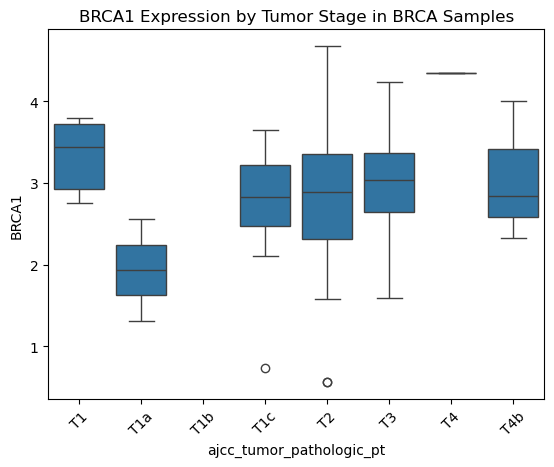

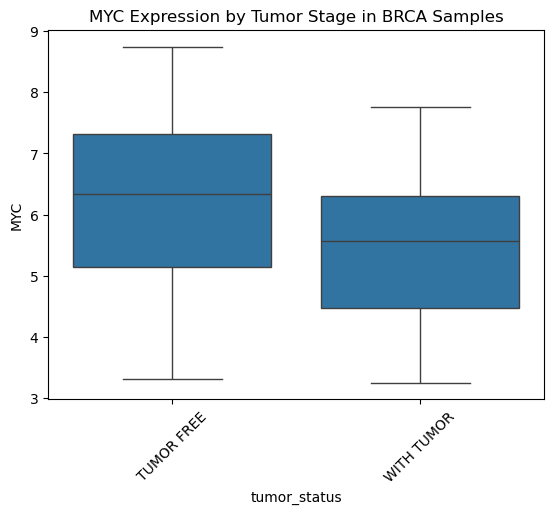

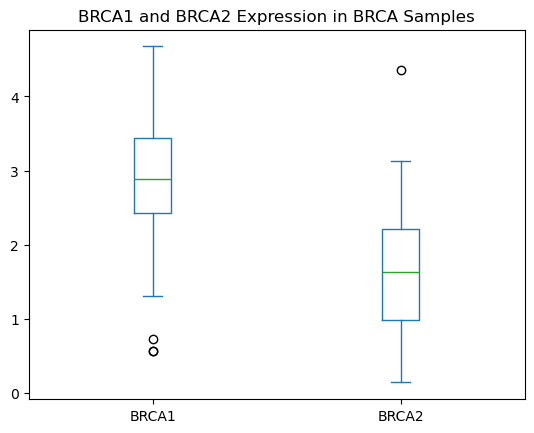

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# %%
# Load the data
####################################################
data = pd.read_csv(
    r"C:\Users\isabe\Downloads\TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    r'C:\Users\isabe\OneDrive\Documents\BME2315\Grosso-Orlando-Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
#print(data.head())

# %%
# Explore the data
####################################################
print(data.shape)
print(data.info())
print(data.describe())

# %%
# Explore the metadata
####################################################
print(metadata_df.info())
print(metadata_df.describe())

# %%
# Subset the data for a specific cancer type
####################################################
cancer_type = 'BRCA'  # Breast Invasive Carcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
#print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
BRCA_data = data[cancer_samples]

# %%
# Subset by index (genes)
####################################################
desired_gene_list = ['TP53', 'BRCA1', 'BRCA2', 'EGFR', 'MYC'] #chosen because they are significantly involved in breast cancer development
gene_list = [gene for gene in desired_gene_list if gene in BRCA_data.index]

# .loc[] is the method to subset by index labels
BRCA_gene_data = BRCA_data.loc[gene_list]

#The following code explores the data and visualizes specific concepts for the samples before we focus on our project goal.

# %%
# Basic statistics on the subsetted data
####################################################
print(BRCA_gene_data.describe())
print(BRCA_gene_data.var(axis=1))  # Variance of each gene across samples
# Mean expression of each gene across samples
print(BRCA_gene_data.mean(axis=1))
# Median expression of each gene across samples
print(BRCA_gene_data.median(axis=1))

# %%
# Explore categorical variables in metadata
####################################################
# groupby allows you to group on a specific column in the dataset,
# and then print out summary stats or counts for other columns within those groups
print(metadata_df.groupby('cancer_type')["ajcc_pathologic_tumor_stage"].value_counts())
#%%
# Explore average age at diagnosis by cancer type
metadata_df['age_at_diagnosis'] = pd.to_numeric(
    metadata_df['age_at_diagnosis'], errors='coerce')
print(metadata_df.groupby(
    'cancer_type')["age_at_diagnosis"].mean())
# %%
# Merging datasets
####################################################
# Merge the subsetted expression data with metadata for BRCA samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
BRCA_metadata = metadata_df.loc[cancer_samples]
BRCA_merged = BRCA_gene_data.T.merge(
    BRCA_metadata, left_index=True, right_index=True)


# %%
# Plotting
####################################################
# Boxplot of BRCA1 and BRCA2 expression in BRCA samples using SEABORN
sns.boxplot(
    data=BRCA_merged,
    x="ajcc_tumor_pathologic_pt",
    y='BRCA1',
    order=["T1", "T1a", "T1b", "T1c", "T2", "T3", "T4", "T4b"]
)
plt.title("BRCA1 Expression by Tumor Stage in BRCA Samples")
plt.xticks(rotation=45)
plt.show()

clean = BRCA_merged[BRCA_merged['tumor_status'].isin(['TUMOR FREE', 'WITH TUMOR'])]
sns.boxplot(
    data = clean,
    x="tumor_status",
    y='MYC',
)
plt.title("MYC Expression by Tumor Stage in BRCA Samples")
plt.xticks(rotation=45)
plt.show()
#%%
# Boxplot of BRCA1 and BRCA2 expression in BRCA samples using PANDAS directly
BRCA_merged[['BRCA1', 'BRCA2']].plot.box()
plt.title("BRCA1 and BRCA2 Expression in BRCA Samples")
plt.show()

# %%

## Data Analysis: 

### Methods
To answer whether sustained growth signaling gene expression can predict tumor stage in breast cancer, we will use supervised classification. Tumor Stage is a discrete label/number(I-IV), and because we have the labeled patient data, classification is the best method to use. Other methods do not work as well, like regression since stage is not a continuous value. Classification will allow us to train a model on known tumor stages and then evaluate whether gene expression patterns are distinct enough to correctly predict which stage a sample belongs to.

Our intial analysis used PCA and K-Means clustering and revealed significant overlap between tumor stages in gene expression space, with no clear separation observed which suggests that classification will likely confirm that sustained growth signaling genes alone are not strong predictors of tumor stage.


*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

#### Merge Datasets

In [10]:
import pandas as pd # Pandas
import numpy as np # Numpy
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.decomposition import PCA

# Load the data
#Christian's filepath
#data = pd.read_csv(
    #r"/Users/christiangrosso/Downloads/TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)  # can also use larger dataset with more genes
#Isabella's filepath
data = pd.read_csv(r"C:\Users\isabe\Downloads\TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)
#metadata_df = pd.read_csv(
    #r'/Users/christiangrosso/Desktop/Comp BME/Grosso-Orlando-Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
metadata_df = pd.read_csv(
    r'C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)

# Subset the data for a specific cancer type
cancer_type = 'BRCA'  # Breast Invasive Carcinoma
# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
# When you want a subset of columns, you can pass a list of column names to the data frame in []
BRCA_data = data[cancer_samples]

# Subset by index (genes)
####################################################
#with open(r"/Users/christiangrosso/Desktop/Comp BME/Grosso-Orlando-Module-4-Cancer/code/Menyhart_JPA_CancerHallmarks_core.txt","r") as f:
    #lines = f.readlines()
with open(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\code\Menyhart_JPA_CancerHallmarks_core.txt","r") as f:
    lines = f.readlines()

#Grab a list with every gene included in the sustained proliferative growth category
sp_line = lines[8].split("\t") #line 9 - index 8
desired_gene_list = [gene.strip() for gene in sp_line if gene.strip() not in ["SUSTAINING PROLIFERATIVE SIGNALING",""]]
desired_gene_list = list(set(desired_gene_list))
gene_list = [gene for gene in desired_gene_list if gene in BRCA_data.index]
#print(desired_gene_list)
# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
BRCA_gene_data = BRCA_data.loc[gene_list]


# Merging datasets
# Merge the subsetted expression data with metadata for BRCA samples,
BRCA_metadata = metadata_df.loc[cancer_samples]
BRCA_merged = BRCA_gene_data.T.merge(
    BRCA_metadata, left_index=True, right_index=True)





In [11]:

#Show merged DataFrame
data = BRCA_merged[gene_list]
data


,GNG11,CCND1,NRG1,PXN,MCL1,KDR,PIK3CD,MAP2K2,DLG4,PLCE1,...,IKBKB,VTN,PTEN,RAP1B,CTNNB1,SYNGAP1,NPM1,SRC,NTRK2,IL27RA
TCGA-E9-A1NI-01A-11R-A14D-07,5.748940,8.438264,0.429335,6.144917,7.816182,3.990601,2.167402,5.879470,3.847687,1.947892,...,4.688935,0.144019,4.939976,5.112027,8.463347,2.692224,8.925769,5.075917,0.691738,3.253639
TCGA-E2-A1LK-01A-21R-A14D-07,3.693874,5.751915,0.071797,5.207232,8.140580,3.400535,1.775482,6.521694,2.676519,2.941662,...,6.429562,0.671206,1.750223,4.842015,9.030750,2.095238,8.258598,5.938626,0.300361,6.390603
TCGA-BH-A0B2-01A-11R-A10J-07,6.633433,6.807775,0.824763,6.435467,8.165650,4.641126,3.834548,6.417489,3.390198,1.908863,...,6.223907,0.432351,5.510356,5.237737,8.640345,2.920158,8.749168,5.733146,2.877526,4.141789
TCGA-E2-A107-01A-11R-A10J-07,5.819327,9.529089,0.310710,7.048787,8.071209,3.807691,2.366955,6.730966,3.617614,0.839721,...,5.914060,0.266536,5.278739,5.728693,8.361235,2.183434,8.097891,5.386299,1.838921,4.681602
TCGA-LL-A5YN-01A-11R-A28M-07,5.348293,6.223058,0.313921,5.871991,7.278051,2.080029,4.502421,7.108668,3.758618,1.521775,...,4.858491,0.619380,4.083655,4.843056,7.175161,2.287566,7.945099,5.514220,0.822202,5.522313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-E9-A5UP-01A-11R-A28M-07,3.758058,8.576706,0.009722,6.223827,8.424985,1.961980,2.834090,6.623484,3.634567,3.362797,...,5.812132,0.885809,4.351434,5.385749,7.609624,2.586720,7.962370,6.151645,3.913583,3.193135
TCGA-AR-A24T-01A-11R-A169-07,7.209918,7.602613,1.268249,6.541219,8.756147,5.191089,3.435871,5.761261,2.846474,1.906186,...,5.895697,0.644353,6.546564,6.326318,8.982775,2.907851,8.860458,5.042587,3.473372,3.024135
TCGA-D8-A1XB-01A-11R-A14D-07,5.907594,8.127685,2.374066,6.446860,8.547165,4.347667,3.210759,6.061135,3.974275,2.068594,...,6.654645,0.753013,5.668772,5.324315,8.844853,3.548805,8.951731,5.430069,2.647450,4.502272
TCGA-E9-A245-01A-22R-A16F-07,5.458693,6.782520,0.374331,5.390534,7.503071,3.533762,2.914904,6.332894,4.256679,1.012331,...,5.431116,5.314539,5.072265,4.955686,7.926376,2.704178,7.806688,4.884678,6.455663,3.423820


### Exploratory Data Analysis

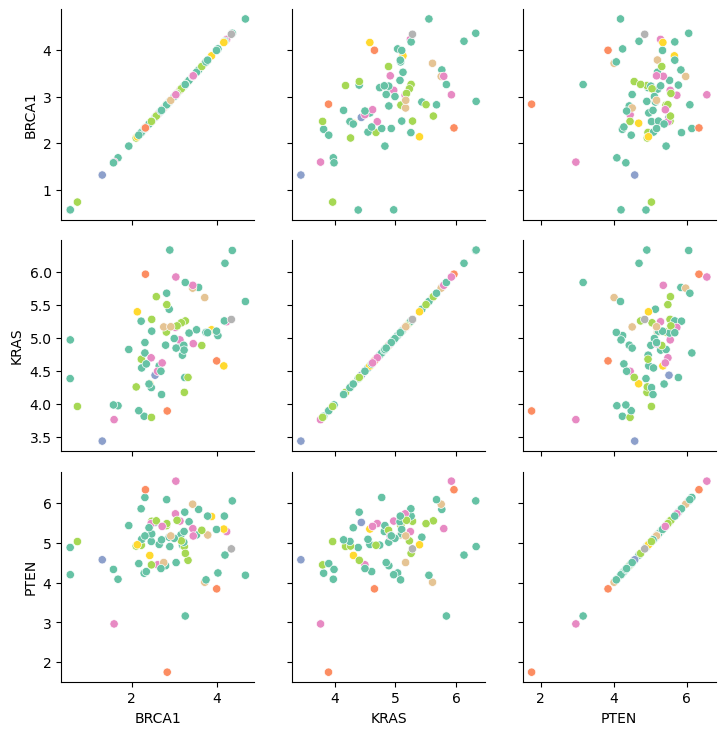

In [12]:

df = BRCA_merged[['BRCA1','KRAS','PTEN']].copy() #Copy dataframe with only expression for 3 genes
df["cluster"] = BRCA_merged['ajcc_tumor_pathologic_pt'].astype(str)
g = sns.PairGrid(df, hue = "cluster", palette = "Set2") #Pair genes with each other to establish a relationship
g.map(sns.scatterplot)
g.add_legend
plt.show()

This grid shows every pairwise combination of three genes. The diagonal is each gene vs. itself (perfect line). The off-diagonal panels are scatterplots between two genes, with points colored by tumor stage. The key takeaway is that tumor stages are completely intermixed in every panel with no stage separates from the others. This indicates that these three genes cannot distinguish tumor stage on their own.

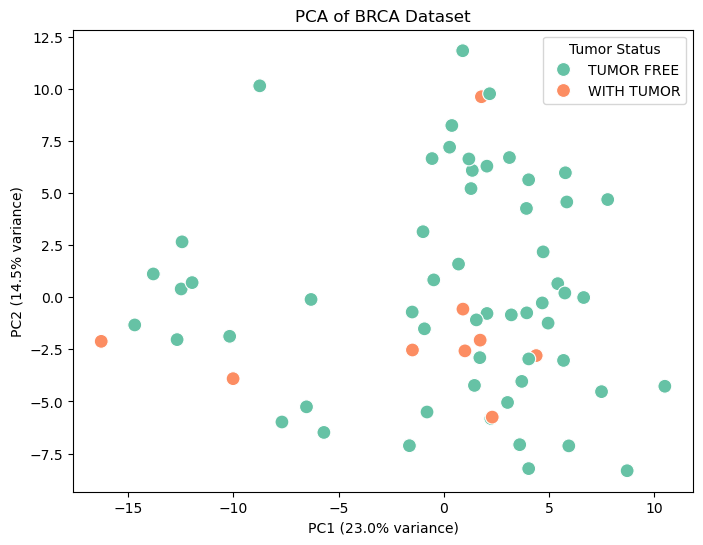

In [13]:
clean = BRCA_merged[BRCA_merged['tumor_status'].isin(['TUMOR FREE', 'WITH TUMOR'])] #Only select samples where tumor status is recorded
top50 = clean[gene_list].var().nlargest(50).index.tolist() #Use 50 genes with highest variability

X = clean[top50]
Y = clean['tumor_status'].astype(str)

pca = PCA(n_components=2) #Graph PCA with 2 components
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=Y,
    palette="Set2",
    s=100
)
plt.title("PCA of BRCA Dataset")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Tumor Status")
plt.show()

The "Tumor Free" and "With Tumor" samples are completely scattered throughout the plot with no separation between the two groups. The orange points appear randomly distributed among teal ones. This suggests that sustained growth signaling gene expression cannot distinguish active tumor presence from tumor-free status in this 2D projection.

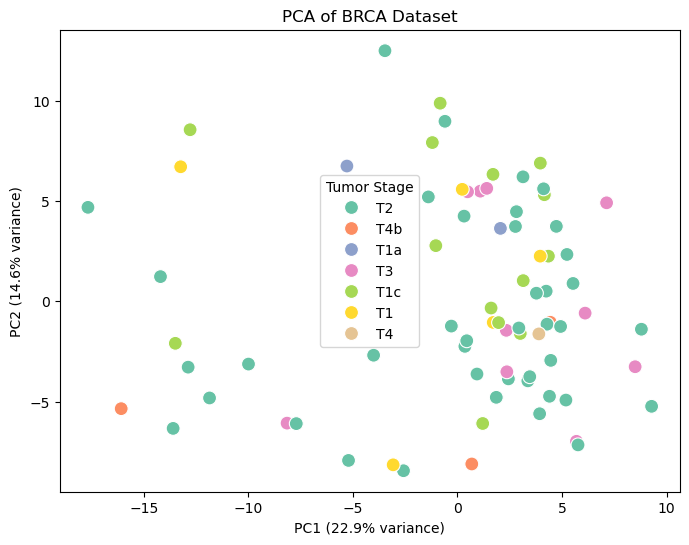

In [14]:
clean2 = BRCA_merged[BRCA_merged['ajcc_tumor_pathologic_pt'].isin(['T1', 'T1a', 'T1b', 'T1c', 'T2', 'T2a', 'T2b', 'T2c', 'T3', 'T3a', 'T3b', 'T3c', 'T4', 'T4a', 'T4b', 'T4c'])] #Clean data so it only contains samples where tumor stage is recorded
top50 = clean2[gene_list].var().nlargest(50).index.tolist() #50 genes with highest variability

X2 = clean2[top50] 
Y2 = clean2['ajcc_tumor_pathologic_pt'].astype(str)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X2) #Make a second PCA using tumor stage rather than status for a more in depth analysis
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=Y2,
    palette="Set2",
    s=100
)
plt.title("PCA of BRCA Dataset")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Tumor Stage")
plt.show()

All tumor stages are completely intermixed across the plot. T2 is scattered everywhere, and minority stages like T1a, T4, and T4b appear randomly embedded among the others with no pattern. There is no region of the plot where any single stage clusters exclusively, confirming that sustained growth signaling gene expression does not separate tumor stages in reduced-dimension space.

### Unsupervised Clustering: K-Means 

c:\Users\isabe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


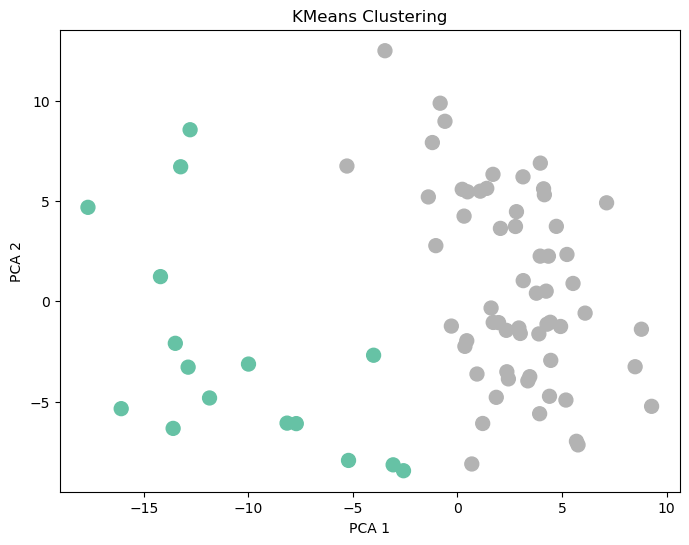

Correct:   50
Incorrect: 26
Accuracy:  0.6579


In [15]:
model = KMeans(n_clusters=2, random_state=0) #K-Means model chosen for simplicity and efficiency in analyzing large datsets
model.fit(X2)
y_pred = model.predict(X2) #predict 2 clusters which ideally would be early and late-stage
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap="Set2", s=100)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clustering")

plt.show()

# We can see above the labels 0 and 1 are mismatched, so if we compared them directly our accuracy would be low. Let's swap labels 0 and 1
y_pred_swapped = y_pred.copy()
y_pred_swapped[y_pred == 1] = 0
y_pred_swapped[y_pred == 0] = 1

#print(y_pred_swapped) Can print this statement to ensure that the binary values were swapped
from sklearn.metrics import accuracy_score
#Chose T1-T2 as early and T3-T4 as late
stage_mapping = {
    'T1': 0, 'T1a': 0, 'T1b': 0, 'T1c': 0,
    'T2': 0, 'T2a': 0, 'T2b': 0,
    'T3': 1,
    'T4': 1, 'T4b': 1
}

Y_assigned = Y2.map(stage_mapping)

#Analyze the value assigned with the actual value to determine the accuracy of the clustering
# Filter both arrays using the same mask
valid_mask = Y_assigned.notna()
Y_assigned = Y_assigned[valid_mask].astype(int)
y_pred_filtered = y_pred_swapped[valid_mask]  
acc = accuracy_score(Y_assigned, y_pred_filtered)

print(f"Correct:   {(Y_assigned.values == y_pred_filtered).sum()}")
print(f"Incorrect: {(Y_assigned.values != y_pred_filtered).sum()}")
print(f"Accuracy:  {acc:.4f}")

KMeans is an unsupervised machine learning model, which sorted the data into 4 clusters based on similarity. It was done on unlabeled data, and after the results were compared to the sample label (tumor stage) and was found to have sorted the data into 2 clusters with approximately 65.8% accuracy. Although this accuracy rate is above randomeness, it is not the best way of displaying and predicting the data. Because this unsupervised model wasn't able to accurately separate the tumor stage data into clusters, a supervised learning model should be used in the future to establish a clear correlation between sustained proliferation genes and tumor stage, leading to a higher accuracy rate.

### Supervised Binary Classification - Logistic Regression

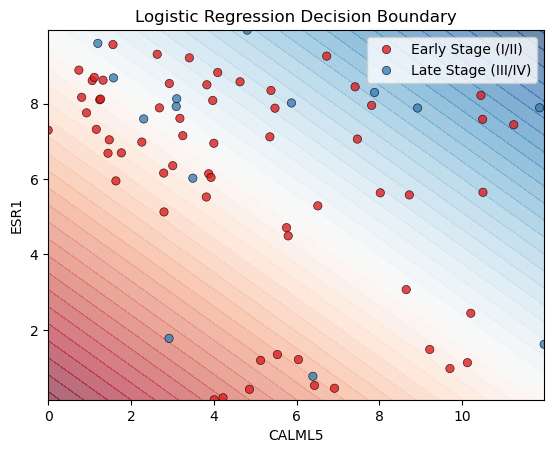

In [ ]:
# %%
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

# %%
# Load the merged BRCA dataset
#data = pd.read_csv(r"C:\Users\ctgrosso\Downloads\BRCA_merged.csv", index_col=0)
data = pd.read_csv(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\data\BRCA_merged.csv", index_col=0)

#Map tumor stages to early (I-II) and late (III-IV)
stage_map = {
    "T1":    0, "T1a":   0, "T1b":   0, "T1c":  0,
    "T2":   0, "T2a":  0, "T2b":  0, "T2c": 0,
    "T3":  1, "T3a": 1, "T3b": 1, "T3c": 1,
    "T4":   1, "T4a":   1, "T4b":    1, "T4c": 1
}
data["stage_binary"] = data["ajcc_tumor_pathologic_pt"].map(stage_map)
data = data.dropna(subset=["stage_binary"]) #remove samples with missing tumor stage

#Separate features (gene expression) from labels (tumor stage)
meta_cols = ["ajcc_tumor_pathologic_pt", "cancer_type", "stage_binary"] 
gene_cols = [col for col in data.columns if col not in meta_cols]

X = data[gene_cols].values #feature matrix
y = data["stage_binary"].values #target labels (0 = early, 1=late)

# %%
#Convert binary labels to stage names
y_label = [{0: "Early Stage (I/II)", 1: "Late Stage (III/IV)"}[i] for i in y]
feature_1 = "CALML5"
feature_2 = "ESR1"
X = data[[feature_1, feature_2]].values


# %%
# Logistic regression

# BUILD A MODEL: 
model = LogisticRegression(penalty=None).fit(X, y)

# PREDICT AND EVALUATE: 
model.predict_proba(X)

# %% Plotting decision boundary

# Create meshgrid
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Compute decision function over the grid
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.6)  # background, will color the plot depending on early or late stage range
plt.contour(xx, yy, Z, levels=[0], colors='black',
            linewidths=2)  # decision boundary
sns.scatterplot(x=X[:, 0],
                y=X[:, 1],
                hue=y_label,
                edgecolors='k',
                palette="Set1",
                alpha=0.8)
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title("Logistic Regression Decision Boundary")
plt.show()



A logistic regression model was trained to classify early vs late tumor stage using 2 genes as the input. The 2 genes CALML5 and ESR1 were chosen as the 2 most variable genes from the PCA visualized above. The decision boundary plot shows that the model separates two classes with gene expression along each axis. However, there is significant overlap between the stages and gene expression. In order to improve this model, a loop was run through every combination of 2 growth genes in order to find a pair that produced the highest training accuracy.

['TGFB2', 'RET']


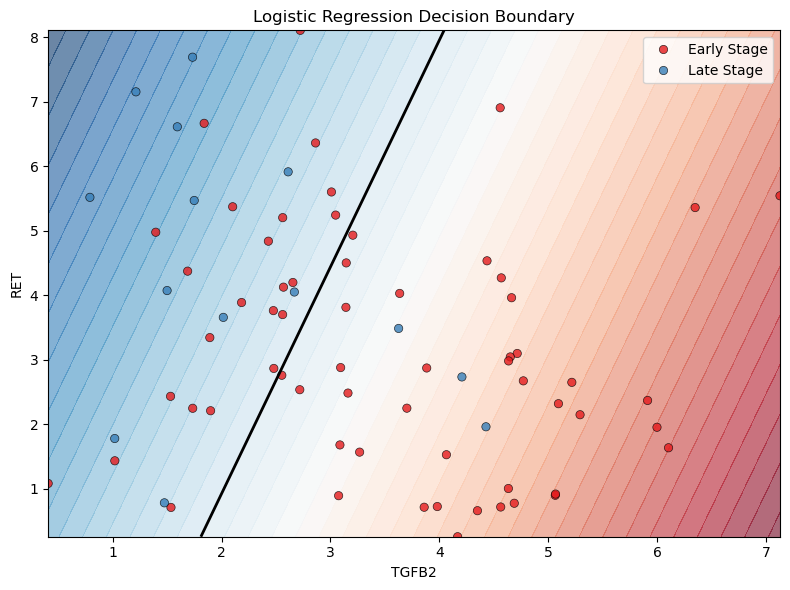

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# %% Load training data
data = pd.read_csv(r"C:\Users\isabe\Downloads\BRCA_merged.csv", index_col=0)

stage_map = {
    "T1": 0, "T1a": 0, "T1b": 0, "T1c": 0,
    "T2": 0, "T2a": 0, "T2b": 0, "T2c": 0,
    "T3": 1, "T3a": 1, "T3b": 1, "T3c": 1,
    "T4": 1, "T4a": 1, "T4b": 1, "T4c": 1
}
data["stage_binary"] = data["ajcc_tumor_pathologic_pt"].map(stage_map)
data = data.dropna(subset=["stage_binary"])
#subset data so that it includes the stages listed under stage map, where they are assigned a binary number

meta_cols = ["ajcc_tumor_pathologic_pt", "cancer_type", "stage_binary",
             "DSS.time", "OS.time", "PFI.time", "DFI.time", "DFI", "PFI", "OS", "DSS",
             "age_at_diagnosis"]
gene_cols = [col for col in data.columns
             if col not in meta_cols and pd.api.types.is_numeric_dtype(data[col])]

y = data["stage_binary"].values

# %% Load validation dataset
BRCA_gene_data = pd.read_csv(
    r"C:\Users\isabe\Downloads\VALIDATION_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)
metadata_df = pd.read_csv(
    r'C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\data\VALIDATION_SET_GSE62944_metadata.csv', index_col=0, header=0)

cancer_samples = metadata_df[metadata_df['cancer_type'] == 'BRCA'].index
BRCA_data = BRCA_gene_data[cancer_samples]

with open(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\code\Menyhart_JPA_CancerHallmarks_core.txt", "r") as f:
    lines = f.readlines()

sp_line = lines[8].split("\t")
desired_gene_list = [gene.strip() for gene in sp_line if gene.strip() not in ["SUSTAINING PROLIFERATIVE SIGNALING", ""]]
desired_gene_list = list(set(desired_gene_list))
gene_list = [gene for gene in desired_gene_list if gene in BRCA_data.index]
BRCA_gene_data_filtered = BRCA_data.loc[gene_list]

BRCA_metadata = metadata_df.loc[cancer_samples]
BRCA_merged_val = BRCA_gene_data_filtered.T.merge(BRCA_metadata, left_index=True, right_index=True)
BRCA_merged_val["stage_binary"] = BRCA_merged_val["ajcc_tumor_pathologic_pt"].map(stage_map)
BRCA_merged_val = BRCA_merged_val.dropna(subset=["stage_binary"])

#Find features shared between BOTH datasets before selecting top genes in order to improve validation accuracy

shared_genes = [g for g in gene_cols if g in BRCA_merged_val.columns]

early = data[data["stage_binary"] == 0][shared_genes]
late  = data[data["stage_binary"] == 1][shared_genes]
diff  = (late.mean() - early.mean()).abs().sort_values(ascending=False)

# Take 20 shared genes, ranked from highest variability into a list
top_features = diff.index[:20].tolist()


# Prepare train/val arrays
X_tr = data[top_features].fillna(0).values
y_tr = data["stage_binary"].values

X_val = BRCA_merged_val[top_features].fillna(0).values
y_val = BRCA_merged_val["stage_binary"].values



# Scale features — critical for Logistic Regression
# By fitting the data to a scale it will be more accurately applied to validation datasets where the data collection is not identical
scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(X_tr)   # fit on train only
X_val_scaled = scaler.transform(X_val)       # apply same scale to val

# %% LOGISTIC REGRESSION
# Use only 2 features for decision boundary plot
plot_features = top_features[:2]
print(plot_features)
X_tr_2d = data[plot_features].fillna(0).values
X_val_2d = BRCA_merged_val[plot_features].fillna(0).values  

model = LogisticRegression(penalty=None, max_iter=1000, class_weight='balanced').fit(X_tr_2d, y_tr)

# Decision boundary plot
x_min, x_max = X_tr_2d[:, 0].min(), X_tr_2d[:, 0].max()
y_min, y_max = X_tr_2d[:, 1].min(), X_tr_2d[:, 1].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) #Plot second logistic regression with 2 of the most variable genes to determine if the model would improve

y_label = ["Late Stage" if val == 1 else "Early Stage" for val in y_tr]

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
sns.scatterplot(x=X_tr_2d[:, 0], y=X_tr_2d[:, 1], hue=y_label,
                edgecolors='k', palette="Set1", alpha=0.8)
plt.xlabel(plot_features[0])
plt.ylabel(plot_features[1])
plt.title("Logistic Regression Decision Boundary")
plt.tight_layout()
plt.show()

Two of the twenty best features chosen for the logistic regression model were RET and TGFB2. Although these genes showed the greatest mean expression difference between early and late stage tumors, the decision boundary still contains significant overlap between classes. This highlights a key limitation of the model: restricting classification to only two genes is likely not sufficient to distinguish between early and late tumor stage, as cancer progression is driven by complex,  interactions from multiple genes that cannot be fully visualized by a two-feature model. 

### Supervised Classification - Decision Tree

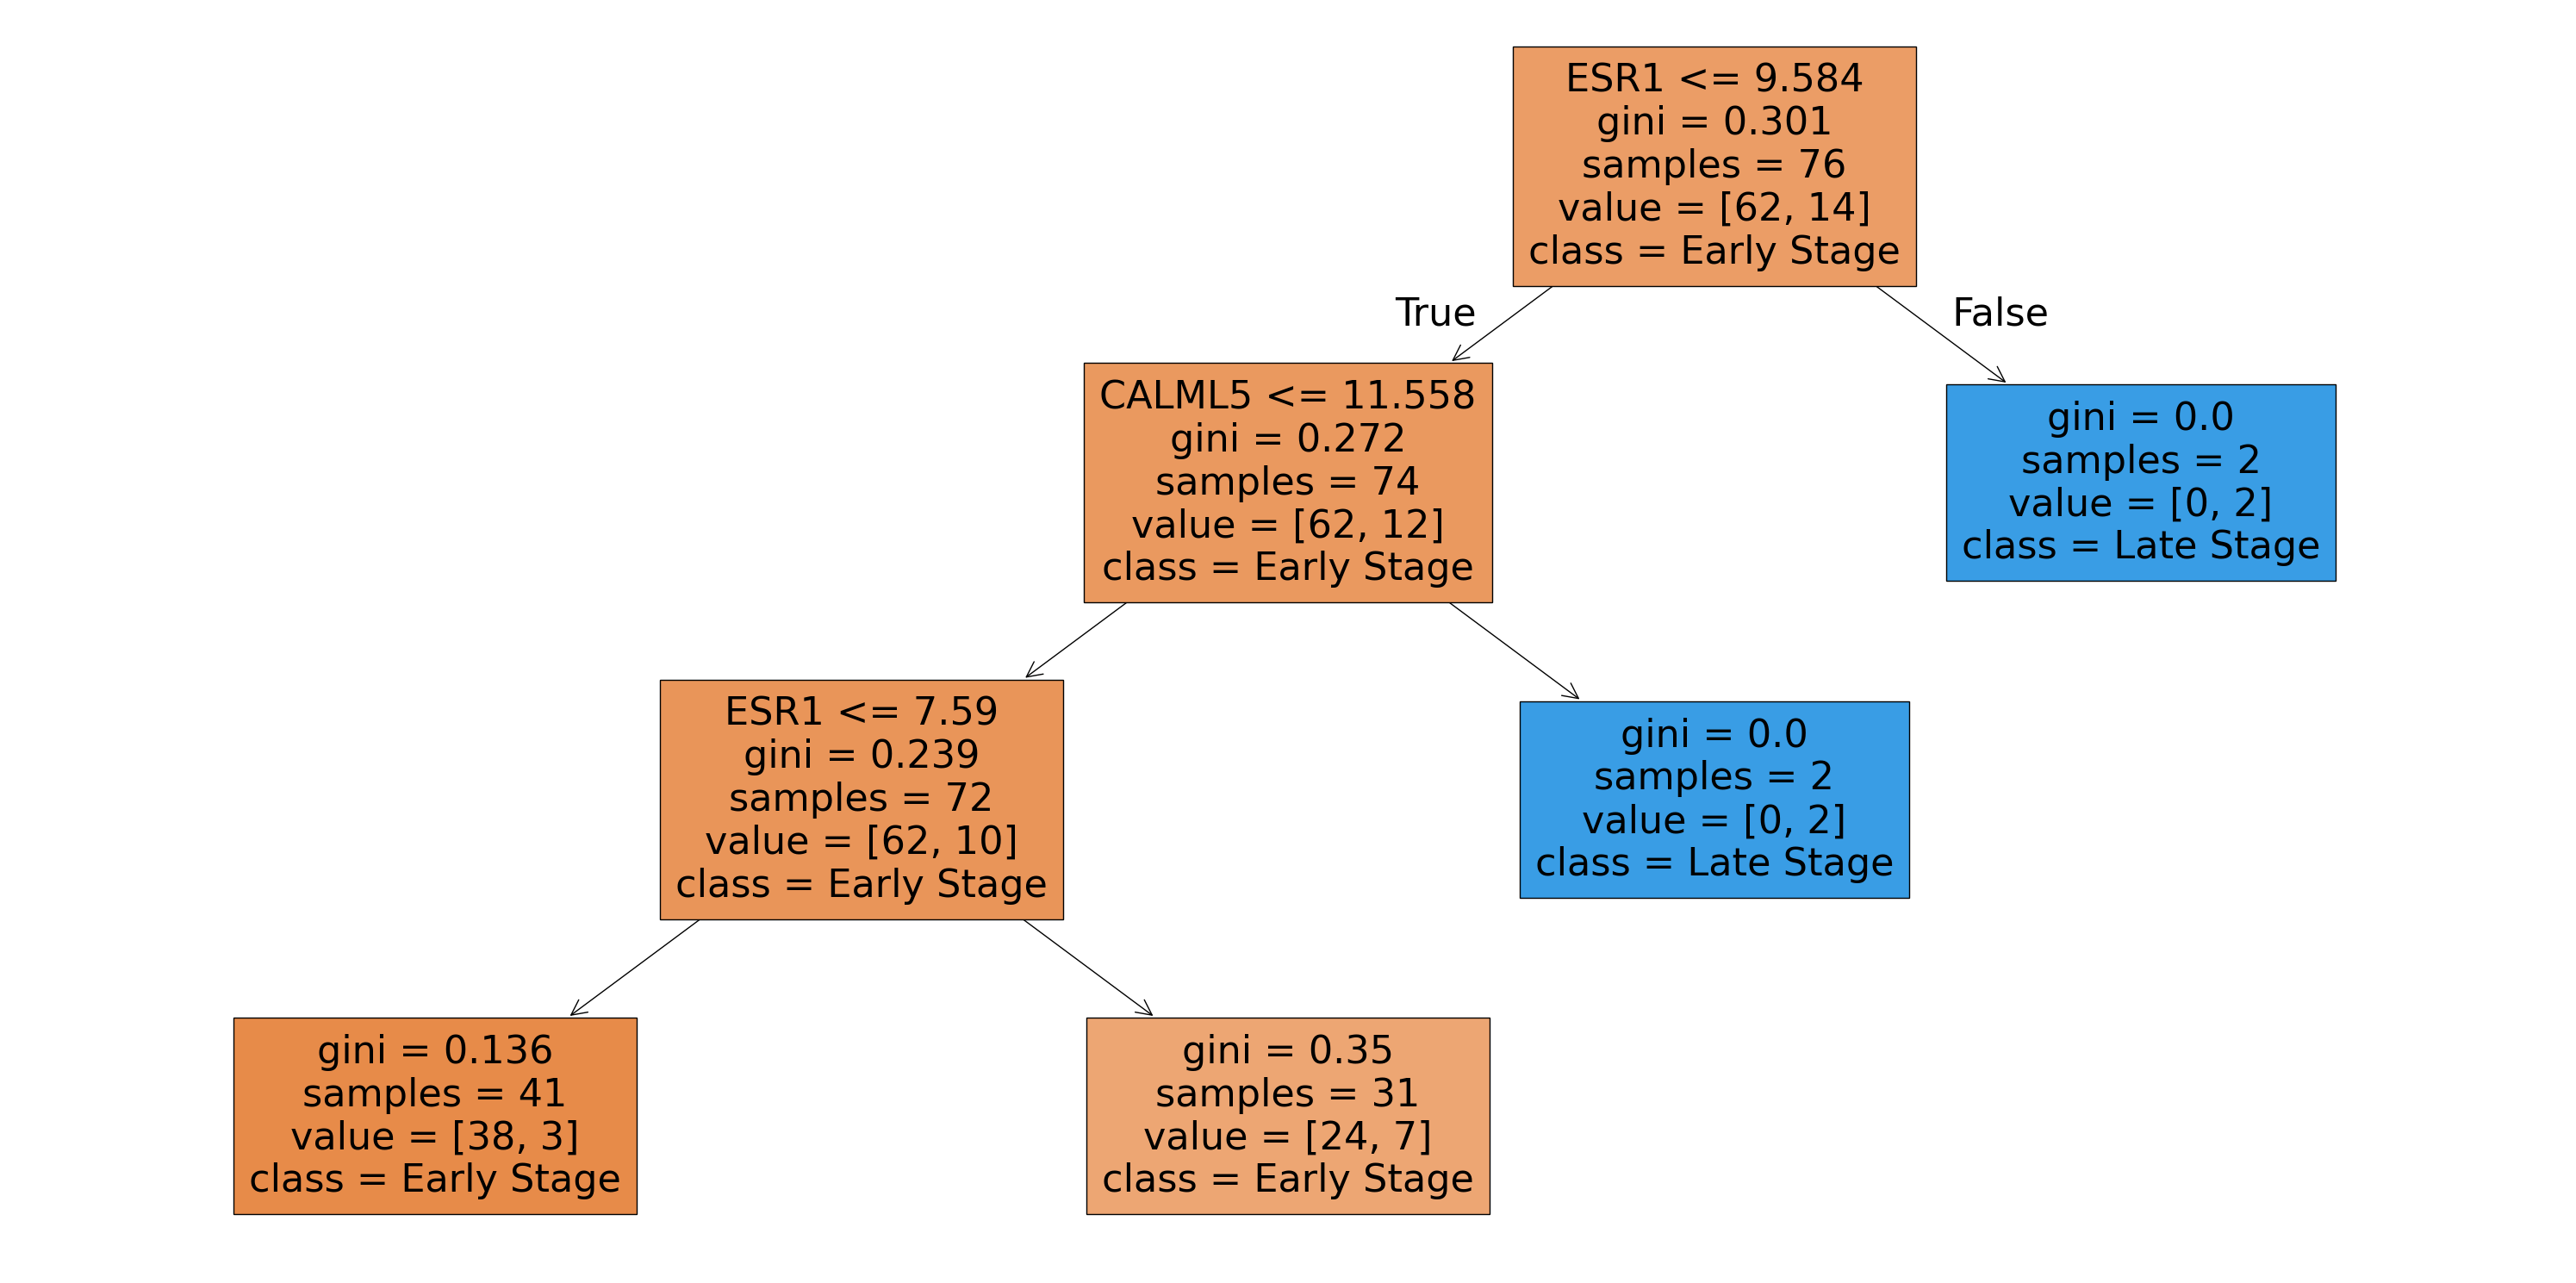

In [20]:
# %% DECISION TREE CLASSIFIER
# BUILD A MODEL: 
plt.figure(figsize=(30, 15)) #ensure tree is visible
dt_model = DecisionTreeClassifier(max_depth=3).fit(X, y)
# %% PLOT DECISION TREE

plt.title("Decision Tree")
plot_tree(dt_model, feature_names=[
          feature_1, feature_2], class_names=["Early Stage", "Late Stage"], filled=True)
plt.tight_layout()
plt.show()


Because ESR1 and CALML5 were the first two genes analyzed with the logistic regression, the decision tree was conducted first with gene expression levels for those 2 genes to keep the pathway similar. It is difficult for the logistic regression to visualize predictions from the dataset. Because we can easily transform the decision tree into a model that evaluates more than 2 genes, we decided to improve on this model to achieve a good accuracy rate. We raised the number of features to the 20 most variable genes and kept the max depth at 3. Although more genes increases more variability, it is important not to increase the depth too high or the model will overfit the data.

Shared genes available: 615
Top features selected: ['TGFB2', 'RET', 'BEX1', 'GATA3', 'TNC', 'CCND1', 'CD79A', 'NGFR', 'SPHK1', 'CDK6', 'SOCS3', 'DOK2', 'MYC', 'CXCL13', 'PTK6', 'IL2RB', 'FOS', 'CCND2', 'KIT', 'ESR1']


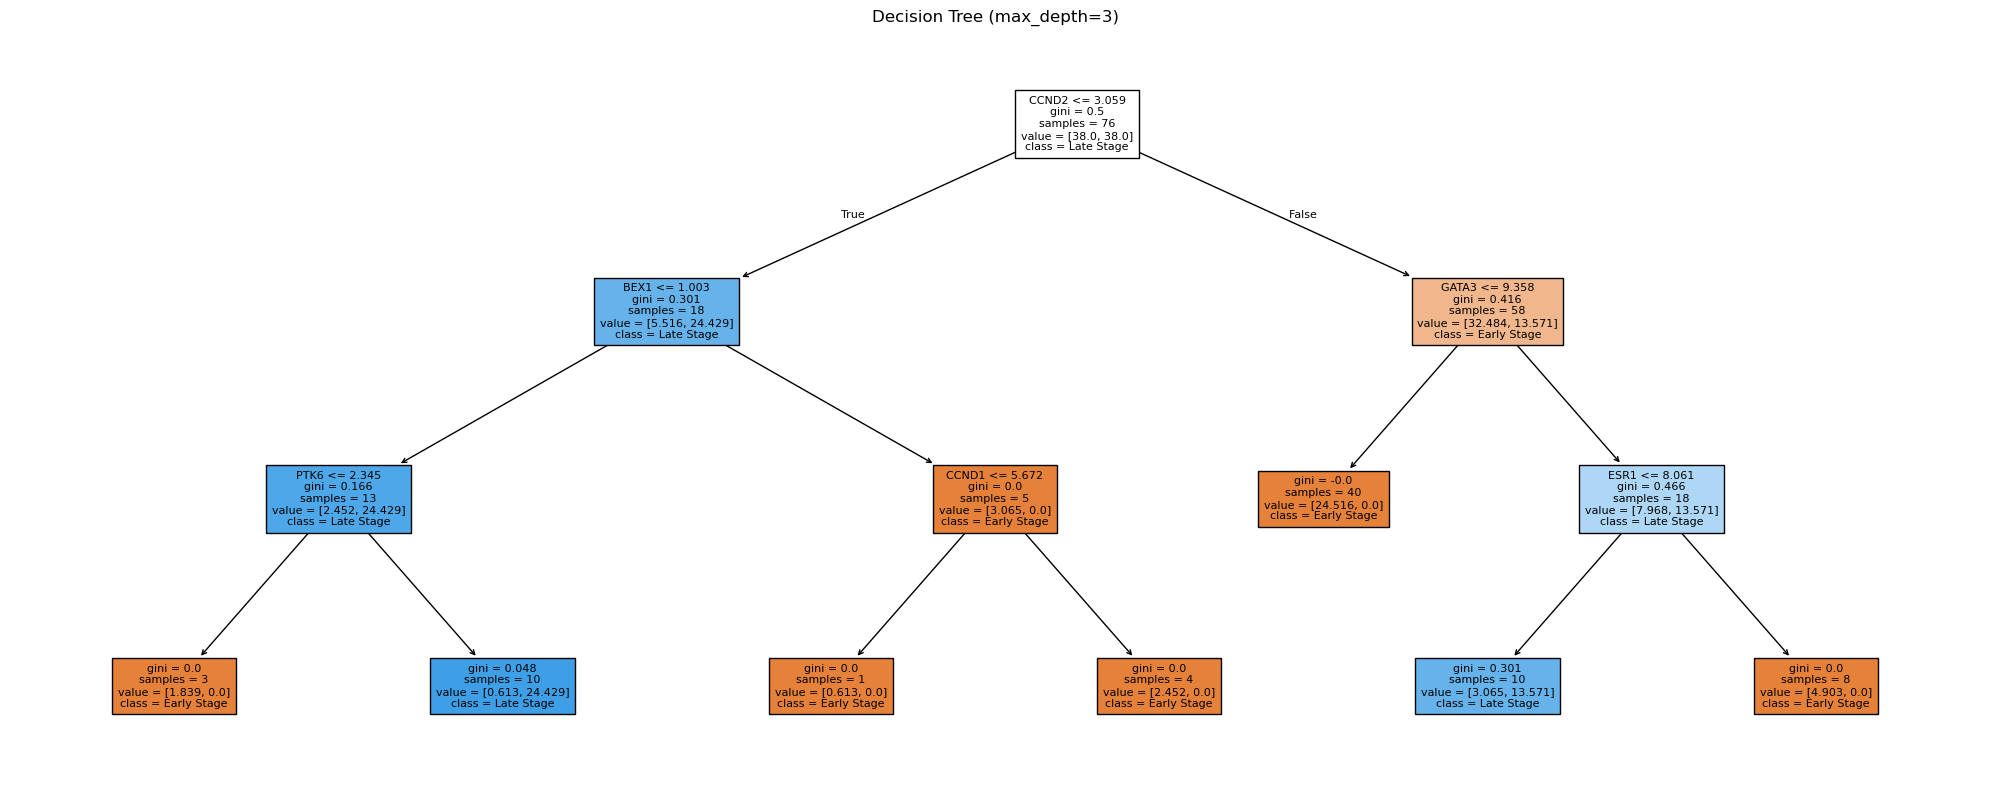

Decision Tree Training accuracy: 0.921


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# %% Load training data
data = pd.read_csv(r"C:\Users\isabe\Downloads\BRCA_merged.csv", index_col=0)
#Ensure that stages are assigned to binary values, and only samples with a tumor stage are included
stage_map = {
    "T1": 0, "T1a": 0, "T1b": 0, "T1c": 0,
    "T2": 0, "T2a": 0, "T2b": 0, "T2c": 0,
    "T3": 1, "T3a": 1, "T3b": 1, "T3c": 1,
    "T4": 1, "T4a": 1, "T4b": 1, "T4c": 1
}
data["stage_binary"] = data["ajcc_tumor_pathologic_pt"].map(stage_map)
data = data.dropna(subset=["stage_binary"])

meta_cols = ["ajcc_tumor_pathologic_pt", "cancer_type", "stage_binary",
             "DSS.time", "OS.time", "PFI.time", "DFI.time", "DFI", "PFI", "OS", "DSS",
             "age_at_diagnosis"]
gene_cols = [col for col in data.columns
             if col not in meta_cols and pd.api.types.is_numeric_dtype(data[col])]

y = data["stage_binary"].values

# %% Load validation dataset
BRCA_gene_data = pd.read_csv(
    r"C:\Users\isabe\Downloads\VALIDATION_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)
metadata_df = pd.read_csv(
    r'C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\data\VALIDATION_SET_GSE62944_metadata.csv', index_col=0, header=0)

cancer_samples = metadata_df[metadata_df['cancer_type'] == 'BRCA'].index
BRCA_data = BRCA_gene_data[cancer_samples]

with open(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-4-Cancer-Grosso-Orlando\Grosso-Orlando-Module-4-Cancer\code\Menyhart_JPA_CancerHallmarks_core.txt", "r") as f:
    lines = f.readlines()

#make sure all proliferative growth genes are initially included, before being subsetted to highest variability
sp_line = lines[8].split("\t")
desired_gene_list = [gene.strip() for gene in sp_line if gene.strip() not in ["SUSTAINING PROLIFERATIVE SIGNALING", ""]]
desired_gene_list = list(set(desired_gene_list))
gene_list = [gene for gene in desired_gene_list if gene in BRCA_data.index]
BRCA_gene_data_filtered = BRCA_data.loc[gene_list]

BRCA_metadata = metadata_df.loc[cancer_samples]
BRCA_merged_val = BRCA_gene_data_filtered.T.merge(BRCA_metadata, left_index=True, right_index=True)
BRCA_merged_val["stage_binary"] = BRCA_merged_val["ajcc_tumor_pathologic_pt"].map(stage_map)
BRCA_merged_val = BRCA_merged_val.dropna(subset=["stage_binary"])

# Find features shared between BOTH datasets before selecting top genes
shared_genes = [g for g in gene_cols if g in BRCA_merged_val.columns]


early = data[data["stage_binary"] == 0][shared_genes]
late  = data[data["stage_binary"] == 1][shared_genes]
diff  = (late.mean() - early.mean()).abs().sort_values(ascending=False)

# Use top 20 shared genes instead of top 2
top_features = diff.index[:20].tolist()

print(f"Top features selected: {top_features}")

# %% Prepare train/val arrays
X_tr = data[top_features].fillna(0).values
y_tr = data["stage_binary"].values

X_val = BRCA_merged_val[top_features].fillna(0).values
y_val = BRCA_merged_val["stage_binary"].values
# %% DECISION TREE
# Max depth 3,4,5 were tested and 3 minimizes overfitting without compromising accuracy of training dataset
#Because the data is off balanced with more early stage tumors, the class weight must be 'balanced'
dt_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced',
                                   random_state=0).fit(X_tr, y_tr)

plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=top_features,
          class_names=["Early Stage", "Late Stage"], filled=True, fontsize=8)
plt.title("Decision Tree (max_depth=3)")
plt.tight_layout()
plt.show()
print(f"Decision Tree Training accuracy: {dt_model.score(X_tr, y_tr):.3f}")


The training accuracy after the number of features was increased is 92.1%. This indicates that by using 20 of the most variably expressed growth genes in BRCA patient sample, the tumor status can be predicted with 92.1% accuracy within this training dataset. In order to verify the accuracy of the models that were created, a validation dataset was used to determine accuracy and develop a confusion matrix.

## Verify and validate your analysis: 

### Validation dataset and confusion matrices

Logistic Regression:
              precision    recall  f1-score   support

 Early Stage       0.82      0.57      0.67        65
  Late Stage       0.18      0.43      0.25        14

    accuracy                           0.54        79
   macro avg       0.50      0.50      0.46        79
weighted avg       0.71      0.54      0.60        79



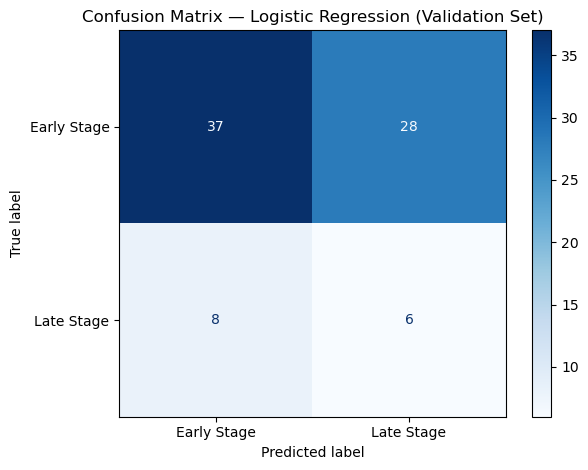

Decision Tree:
              precision    recall  f1-score   support

 Early Stage       0.88      0.80      0.84        65
  Late Stage       0.35      0.50      0.41        14

    accuracy                           0.75        79
   macro avg       0.62      0.65      0.63        79
weighted avg       0.79      0.75      0.76        79



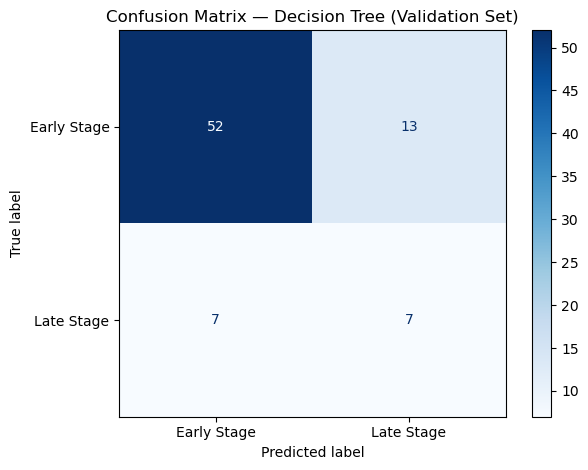

Logistic Regression Training accuracy: 0.658
Logistic Regression Validation accuracy: 0.544
Decision Tree Training accuracy: 0.921
Decision Tree Validation accuracy: 0.747


In [ ]:

# Logistic Regression results
y_pred_lr = model.predict(X_val_2d)
print("Logistic Regression:")
print(classification_report(y_val, y_pred_lr, target_names=["Early Stage", "Late Stage"]))
cm = confusion_matrix(y_val, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Early Stage", "Late Stage"]) #Assign a confusion matrix to validation results for Logistic Regression
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression (Validation Set)")
plt.tight_layout()
plt.show()

# Decision Tree results
y_pred_dt = dt_model.predict(X_val)
print("Decision Tree:")
print(classification_report(y_val, y_pred_dt, target_names=["Early Stage", "Late Stage"]))
cm = confusion_matrix(y_val, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Early Stage", "Late Stage"]) #Assign a confusion matrix to validation datset for decision tree
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Decision Tree (Validation Set)")
plt.tight_layout()
plt.show()

print(f"Logistic Regression Training accuracy: {model.score(X_tr_2d, y_tr):.3f}")
print(f"Logistic Regression Validation accuracy: {model.score(X_val_2d, y_val):.3f}")


print(f"Decision Tree Training accuracy: {dt_model.score(X_tr, y_tr):.3f}")
print(f"Decision Tree Validation accuracy: {dt_model.score(X_val, y_val):.3f}")


As we made slight changes to each classification model, the model visually improved. For the logistic regression, we were able to notice slightly better correlation between the decision boundary and the classification of the sample as early or late stage. However, the model could not make a significant distinction on tumor stage based on the 2 input features - RET and TGFB2 - so we focused on the decision tree model. By focusing on the number of features as well as the max depth of the model, we were able to attain a 92.1% accuracy for the training data set and a 74.7% for the validation dataset.

The gap between datasets for the decision tree demonstrates a challenge in overgeneralizing gene expression patterns across
independently collected datasets​​, which can be due to a variety of factors, including different sequencing and processing procedures​ or different patient population and diagnosis criteria.

### Verification and Validation

While hundreds of genes can contribute to breast cancer stage, this study demonstrates 20 highly variable genes can produce 92.1% training accuracy and 74.7% accuracy from a validation dataset​.

The results can be verified because several of the 20 genes selected (including MYC and CDK6) are known oncogenes which contribute to tumor growth and progression​. This verification confirms the model is accurately identifying genes that are expressed differently in early and late stage tumors​

To validate our project we read a 2021 study published in IEEE that used RNA-Seq gene expression data to predict cancer staging through binary classification [1]​. Their created model achieved 82% accuracy in predicting cancer stages through
binary classification – with I and II being early and III and IV being late​. The paper also identifies PAM50, a genetic sequencing tool, that is currently used for breast cancer prognosis. This acknowledges the ability of gene expression to predict tumor stage as it is currently being used in clinical settings.

## Conclusions and Ethical Implications: 

Conclusions:

Ethical Implication: 
- Clinical Communication: Because the current model is not 100% accurate, there is an ethical risk of misdiagnosis; future work must focus on clear communication of model uncertainty to prevent clinical misinterpretation.
- Training Model Bias: The training dataset must be comprehensive to ensure the model can
make correct generalizations across other patient populations.

## Limitations and Future Work: 

Limitations: Subsetting Constraints: To improve analysis efficiency and due to the uneven distribution of cancer stages, the original dataset was subsetted into "Early Stage" and "Late Stage" Cancer. This may have limit the model's ability to capture the full biological diversity of each tumor stage. By using a larger data set that is more balanced among tumor stages, we could develop a model that can accurately predict tumor stage, rather than early or late-stage cancer. Additionally, due to the time and scope of this project our model training only included two types of models - logistic regression and a decision tree. There may be other models that are better able to capture and predict the data.

Future Work: In the future, it could be investigated whether other "hallmarks of cancer" provide the distinct genetic signatures that are missing from our current focus on sustained growth signaling. It is possible that growth signaling genes alone are not enough to predict the tumor stage. Alternatively, the model might be more accurate if we introduce another dimension of cancer. To further expand on the existing project we can use different models to display the data in a way that could be more accurate and able to generalize to other datasets. By choosing a Sci-Kit learning model that can adapt to independently collected datasets in a standardized way, we might be abe to increase the accuracy of our validation dataset.



AI Statement: AI was used to assist in this project

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*